In [2]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import polars as pl
import polars.selectors as cs
from functools import partial
os.environ["PATH"] = os.environ["PATH"] + ":/opt/homebrew/bin"

from jetutils.definitions import DATADIR, DUNCANS_REGIONS_NAMES, MONTH_NAMES, FIGURES, get_region, polars_to_xarray
from jetutils.data import standardize
from jetutils.geospatial import *
from jetutils.jet_finding import *
from jetutils.plots import *
from jetutils.anyspell import *
from jetutils.anyspell import make_daily, mask_from_spells_pl, subset_around_onset
import altair as alt
alt.data_transformers.enable("vegafusion")

%load_ext IPython.extensions.autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.print_figure_kwargs = {'bbox_inches':None}

basepath = Path(f"{DATADIR}/exp8")

No shap


In [3]:
ALL_TIMES = (
    pl.datetime_range(
        start=pl.datetime(1959, 1, 1),
        end=pl.datetime(2023, 1, 1),
        closed="left",
        interval="6h",
        eager=True,
        time_unit="ms",
    )
    .rename("time")
    .to_frame()
)
summer_filter = (
    ALL_TIMES
    .filter(pl.col("time").dt.month().is_in([6, 7, 8, 9]))
    .filter(pl.col("time").dt.ordinal_day() > 166)
)
summer = summer_filter["time"]
summer_daily = summer.filter(summer.dt.hour() == 0)
big_summer = ALL_TIMES.filter(pl.col("time").dt.month().is_in([6, 7, 8, 9]))
big_summer_daily = big_summer.filter(big_summer["time"].dt.hour() == 0)

summer_doy = summer_daily.dt.ordinal_day().unique()
n_bootstraps = 100

all_jets_one_df = pl.read_parquet(basepath.joinpath("all_jets_one_df.parquet")).cast({"time": pl.Datetime("ms")})

over_europe = pl.col("lon") > -10
lat_over_europe = (pl.col("lat") * pl.col("s")).filter(over_europe).sum() / pl.col("s").filter(over_europe).sum()
lat_over_europe = all_jets_one_df.group_by("time", "jet ID").agg(lat_over_europe.fill_nan(0).alias("lat_over_europe"))

props_uncat = pl.read_parquet(basepath.joinpath("props_as_df_uncat.parquet")).cast({"time": pl.Datetime("ms")})
props_uncat = props_uncat.join(lat_over_europe, on=["time", "jet ID"])

phat_filter = (pl.col("is_polar") < 0.5) | ((pl.col("is_polar") > 0.5) & (pl.col("int") > 1.3e8))
phat_jets = all_jets_one_df.filter((pl.col("is_polar").mean().over(["time", "jet ID"]) < 0.5) | ((pl.col("is_polar").mean().over(["time", "jet ID"]) > 0.5) & (pl.col("int").mode().first().over(["time", "jet ID"]) > 1.3e8)))

phat_jets_catd = phat_jets.with_columns(**{"jet ID": (pl.col("is_polar").mean().over(["time", "jet ID"]) > 0.5).cast(pl.UInt32())})
phat_props = props_uncat.filter(phat_filter)

cross_catd_ofile = basepath.joinpath("cross_catd.parquet")
if cross_catd_ofile.is_file():
    cross_catd = pl.read_parquet(cross_catd_ofile)
else:
    cross_catd = track_jets(phat_jets_catd)
    cross_catd.write_parquet(cross_catd_ofile)
    
pers = pers_from_cross_catd(cross_catd)
phat_props = phat_props.join(pers["time", "jet ID", "pers"], on=["time", "jet ID"])
jet_pos_da = jet_position_as_da(phat_jets)

phat_props_catd = average_jet_categories(phat_props, polar_cutoff=0.5)
double_jet_index = get_double_jet_index(jet_pos_da, diff_cat=False)
phat_props_catd = phat_props_catd.join(double_jet_index, on="time")
phat_props_catd = phat_props_catd.join(phat_props_catd.rolling("time", period="2d", group_by="jet").agg(**{f"{col}_var": pl.col(col).var() for col in ["mean_lon", "mean_lat", "mean_s", "s_star"]}), on=["time", "jet"])
phat_props_catd = phat_props_catd.with_columns(cs.numeric().cast(pl.Float32()))

phat_props_catd_summer = summer_filter.join(phat_props_catd, on="time")

In [15]:
season = [6, 7, 8, 9]
predictors = prepare_predictors(
    phat_props_catd,
    subset=["mean_lon", "mean_lat", "mean_lev", "s_star", "width", "wavinessR16", "pers", "int"],
    anomalize=True,
    standardize=True,
    detrend=True,
    nan_method="nearest",
    season=season,
    lags=[0, 8, 16, 24],
)
t = pl.read_parquet(basepath.joinpath("region_T_6H.parquet"))
qs = [0.84, 0.9, 0.93, 0.95, 0.97, 0.96]
regions = t["region"].unique()
col = pl.col("t2m")
reg = pl.col("region")
expr = pl
for r, q in zip(regions, qs):
    expr = expr.when(reg == r).then(col > col.quantile(q))
# t.filter(pl.col("region").is_in([1, 2]))
spells, targets = prepare_targets_from_ts(t, expr=expr, season=season, minlen=datetime.timedelta(days=5))
for i in targets["region"].unique():
    print(spells.filter(pl.col("region") == i)["spell"].n_unique())
base_pred = regress_against_time(targets)

24
20
21
26
26
26


# predictions, feature importance

In [ ]:
full_pred, scores, feature_importances = predict_all(predictors, targets, base_pred, compute_shap=False, model_type="xgb")
feature_importances = feature_importances.unpivot(index=["importance_type", "lag", "region", "fold"]).pivot("importance_type", index=["lag", "region", "fold", "variable"])


100%|██████████| 24/24 [01:27<00:00,  3.63s/it]


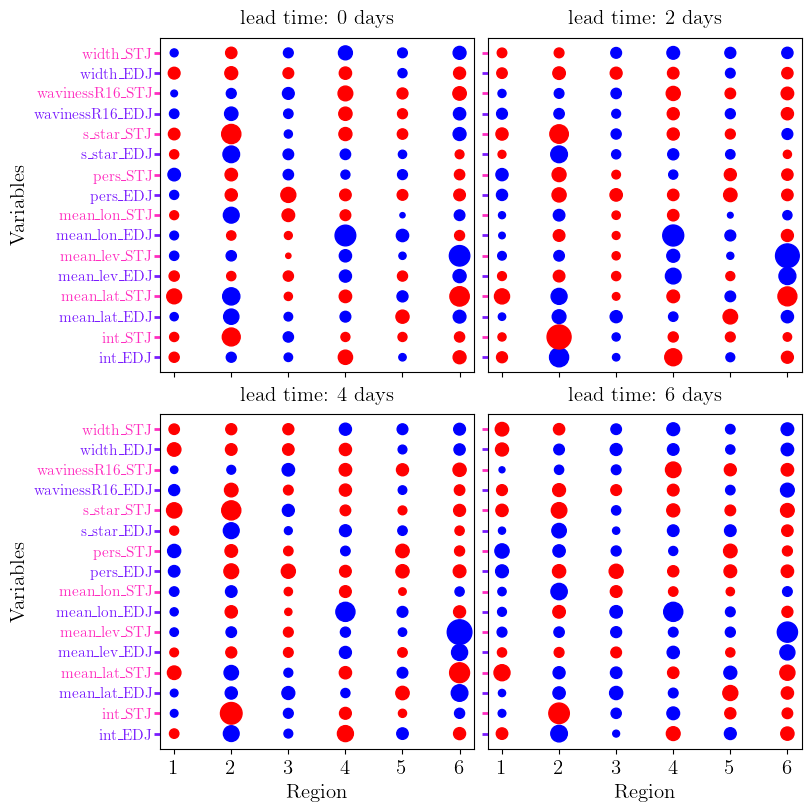

In [40]:
feature_importances_ds = polars_to_xarray(feature_importances, ["region", "lag", "fold", "variable"])
feature_importances_ds = feature_importances_ds.isel(fold=0)
varnames = feature_importances_ds.variable.values

lead_times = feature_importances_ds.lag.values
regions = feature_importances_ds.region.values
fig, axes = plt.subplots(2, 2, figsize=(8, 8), constrained_layout=True, sharey='all', sharex="all")
axes = axes.ravel()
x = np.arange(len(regions))
y = np.arange(len(varnames))
meshgrid = np.meshgrid(x, y)

for i, (ax, lead_time) in enumerate(zip(axes, lead_times)):
    s = feature_importances_ds["permutation"].sel(lag=lead_time).values.squeeze()
    c = feature_importances_ds["correlation"].sel(lag=lead_time).values.squeeze()
    c = np.sign(c)
    ax.scatter(*meshgrid, s=s * 500, c=c, cmap='bwr', vmin=-1, vmax=1)
    
    ax.set_title(f'lead time: {lead_time.astype("timedelta64[D]")}')
    if i in [2, 3]:
        ax.set_xlabel('Region')
    ax.set_xticks(x, regions)
    if i in [0, 2]:
        ax.set_ylabel('Variables')
    yticks = ax.set_yticks(np.unique(y), varnames, rotation=0, ha="right", fontsize=11)
    ax.tick_params(axis="y", length=4, width=2, pad=1)
    for j, tick in enumerate(yticks):
        tick._apply_params(color=COLORS[1 + j % 2], labelcolor=COLORS[1 + j % 2])
fig.savefig(f"{FIGURES}/hot_pred/importance.png")

# jet props around hws

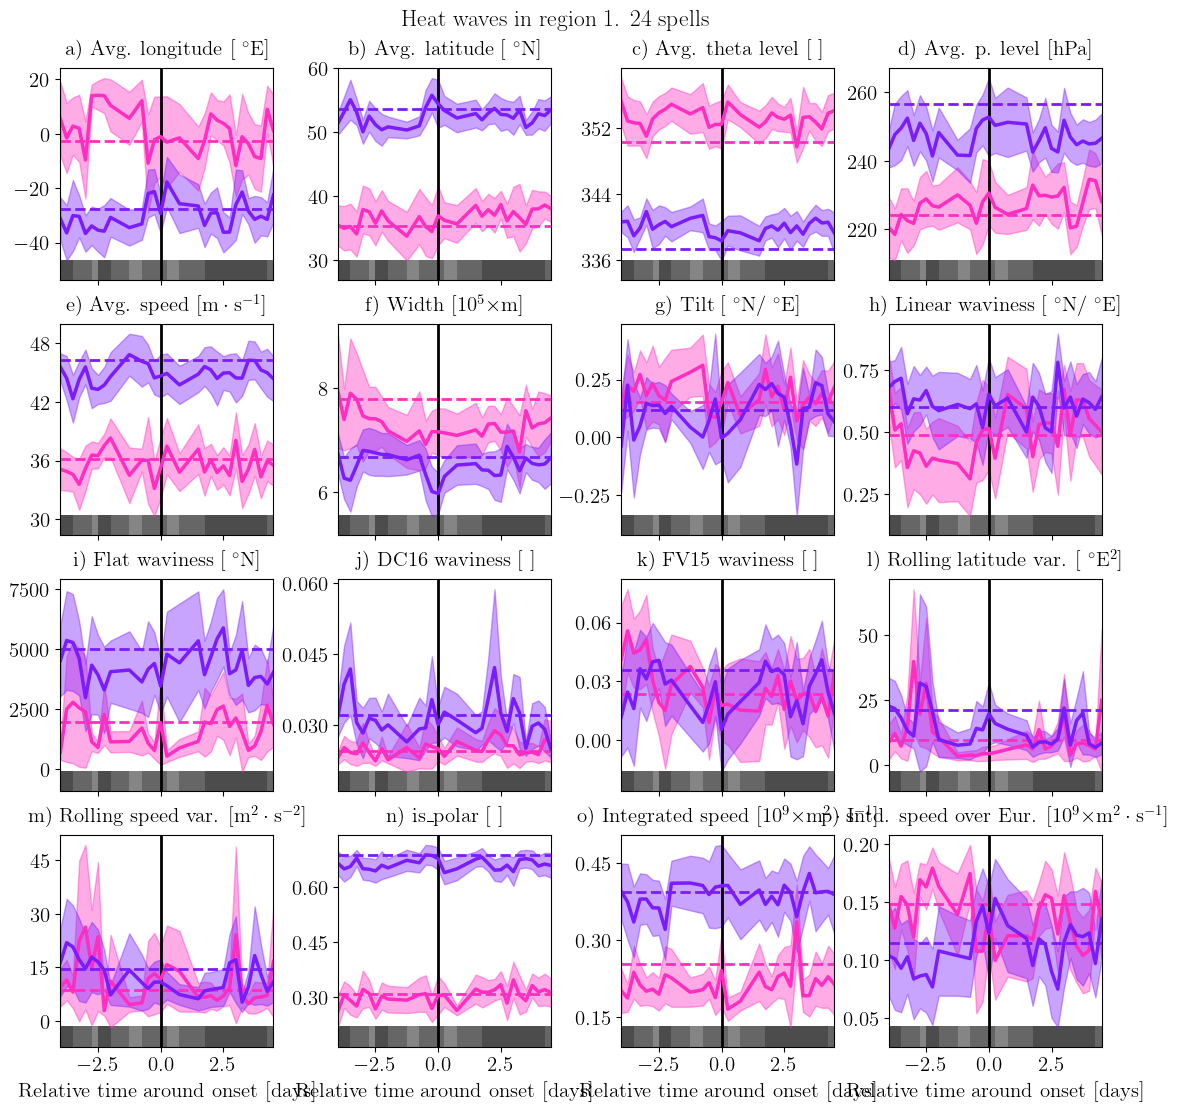

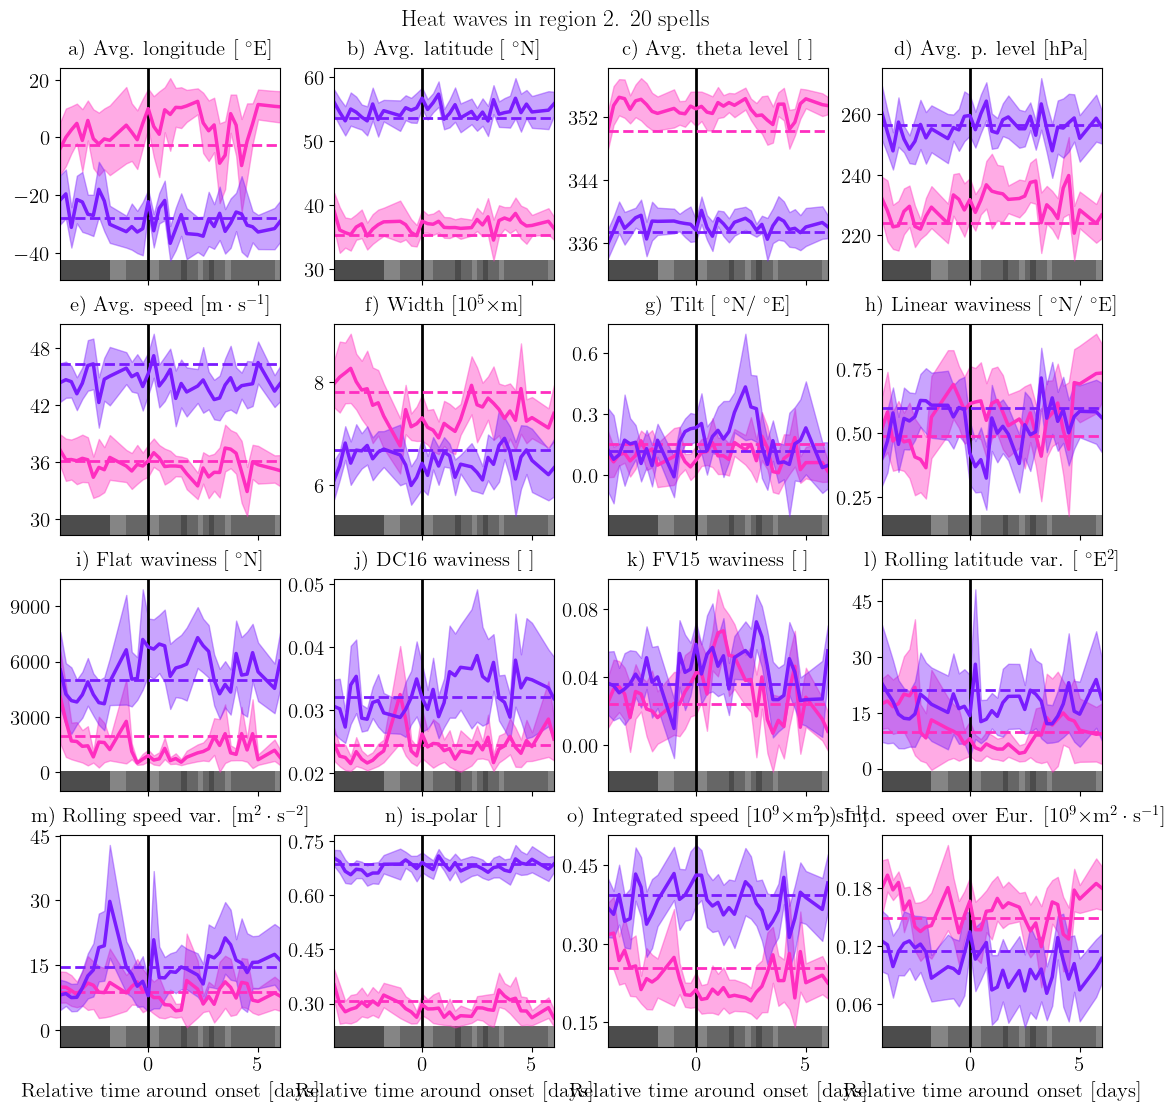

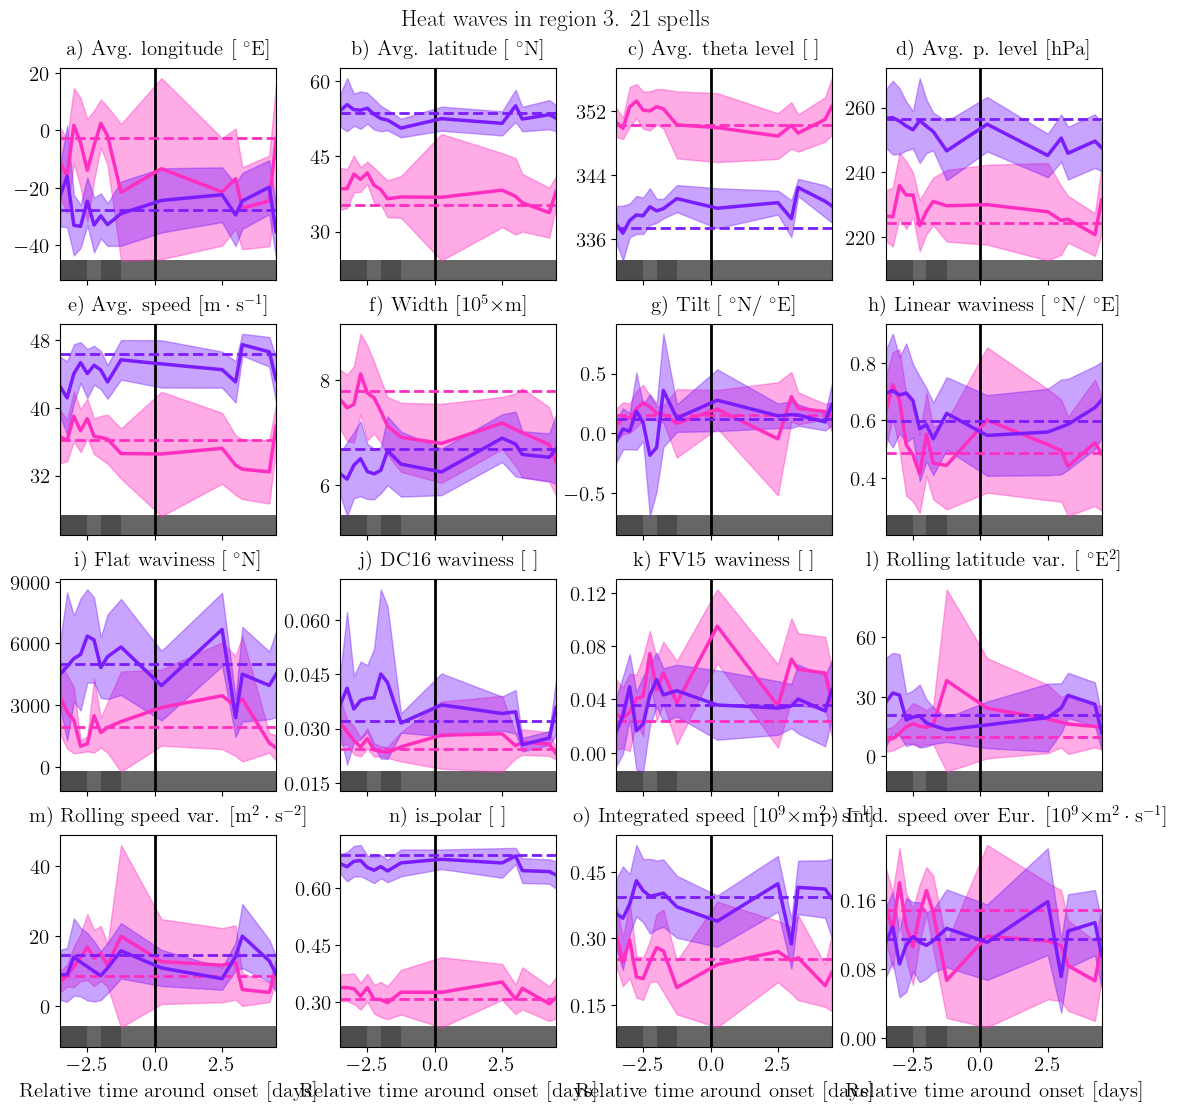

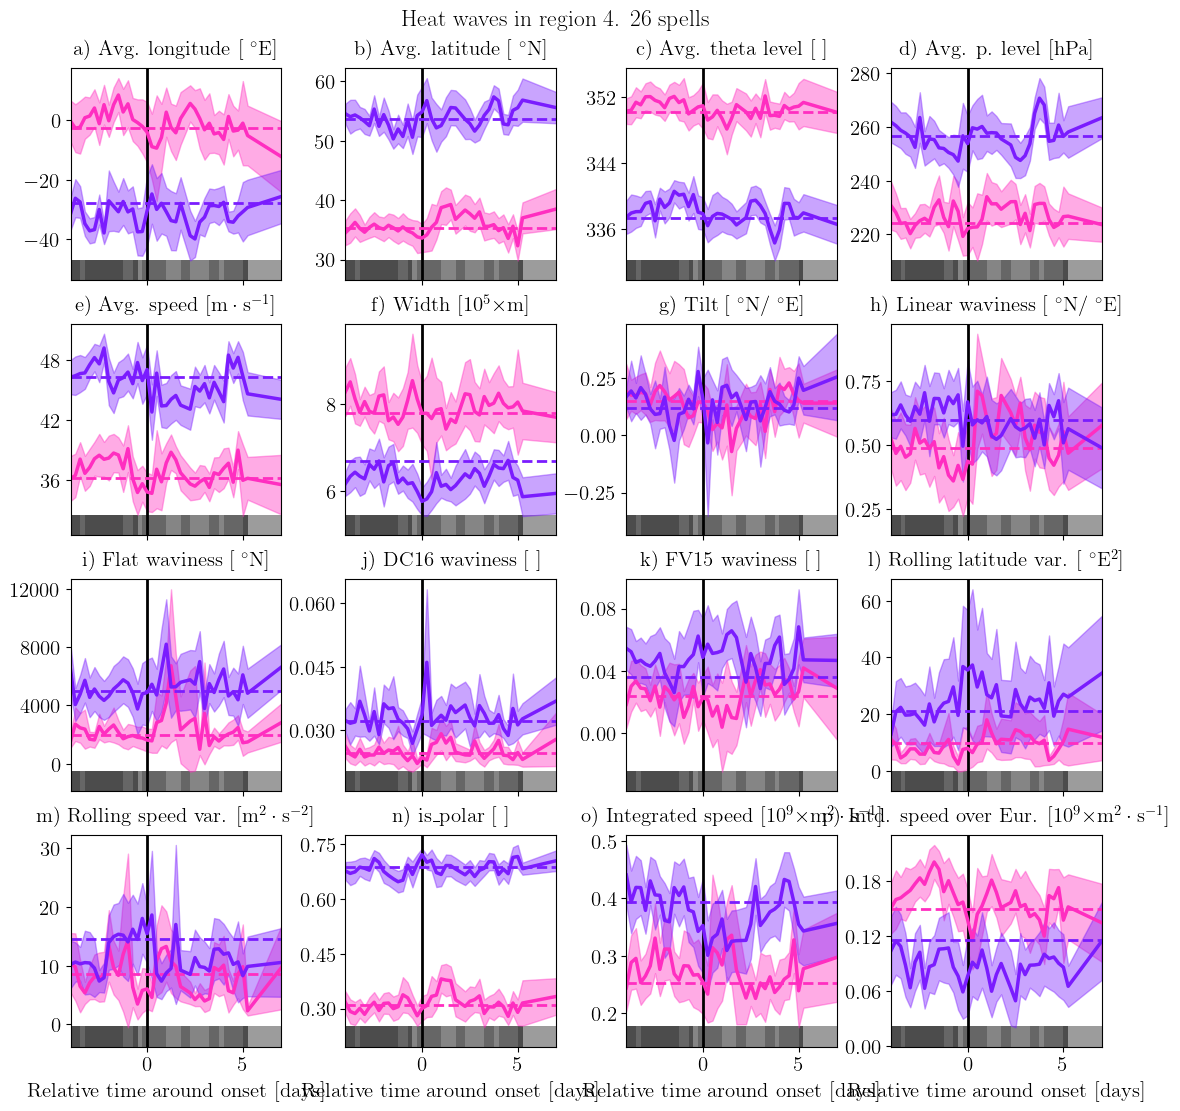

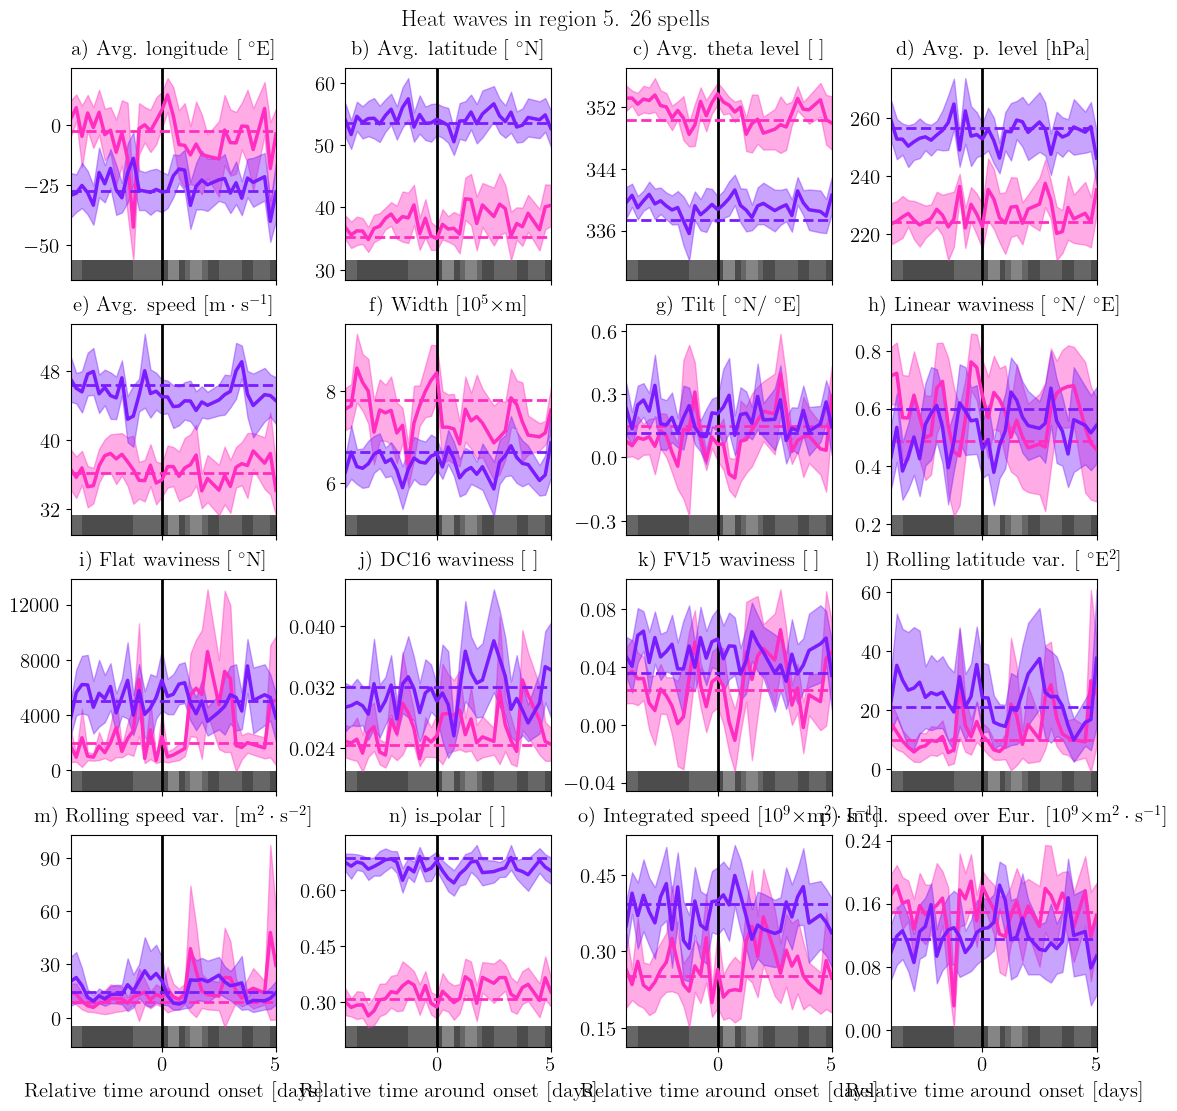

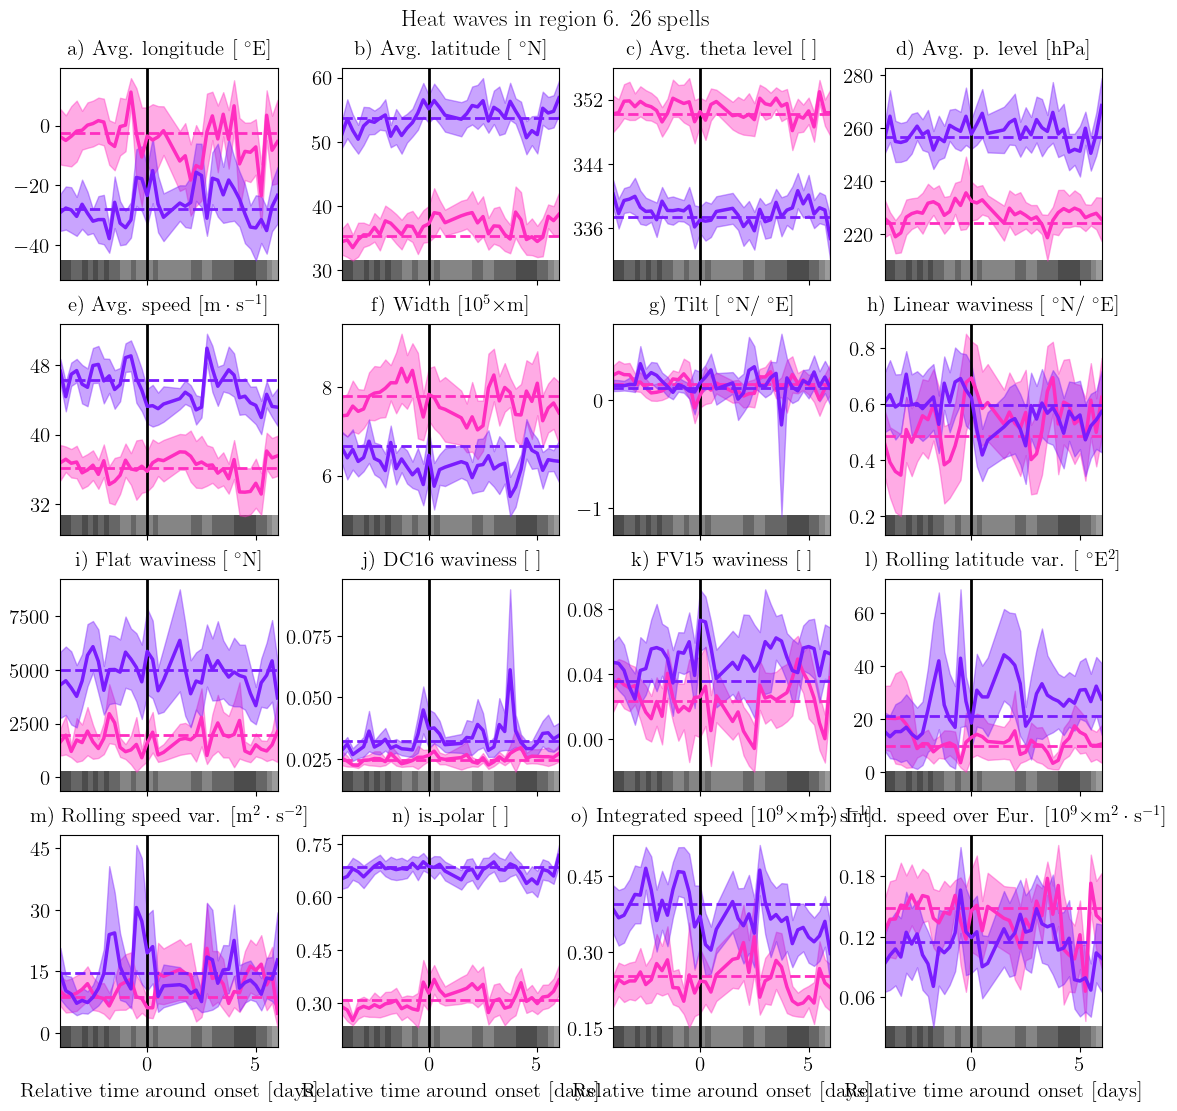

In [17]:
from scipy.stats import norm, chi2, t
from string import ascii_lowercase
data_vars = [
    "mean_lon",
    "mean_lat",
    "mean_theta",
    "mean_lev",
    "mean_s",
    "width",
    "tilt",
    "waviness1",
    "waviness2",
    "wavinessDC16",
    "wavinessFV15",
    "mean_lat_var",
    "mean_s_var",
    "is_polar",
    "int",
    "int_over_europe"
]

def func(col):
    if ':' in col and col.split(":")[-1] == "var":
        return pl.col(col.split(":")[0]).var()
    return pl.col(col).mean()


def mean_confidence(col: pl.Series, q: float) -> pl.Series:
    n = (col.is_not_null() & col.is_not_nan()).sum()
    mu = col.mean()
    s_sq = col.var()
    if s_sq is None:
        return None
    s = np.sqrt(s_sq)
    sign = 1 - 2 * int(q < 0.5)
    q = q if q < 0.5 else 1 - q
    if n > 10:
        to_ret = mu + sign * np.abs(norm.ppf(q=q)) / np.sqrt(n) * s
    else:
        to_ret = mu + sign * s / np.sqrt(n) * t.ppf(q=1 - q, df=n - 1)
    to_ret = np.clip(to_ret, mu - 5 * s, mu + 5 * s)
    return to_ret


def var_confidence(col: pl.Series, q) -> float:
    n = (col.is_not_null() & col.is_not_nan()).sum()
    s_sq = col.var()
    if s_sq is None:
        return None
    sign = 1 - 2 * int(q < 0.5)
    if n > 50:
        q = q if q < 0.5 else 1 - q
        to_ret = s_sq + sign * np.sqrt(2 / n) * np.abs(norm.ppf(q)) * s_sq
    else:
        to_ret = (n - 1) * s_sq / chi2.ppf(1 - q, df=n - 1)
    return np.clip(to_ret, 0, s_sq * 2)
        
    
def func_q(col, q):
    if ':' in col and col.split(":")[-1] == "var":
        return pl.col(col.split(":")[0]).map_batches(partial(var_confidence, q=q), return_dtype=pl.Float64(), returns_scalar=True)
    return pl.col(col).map_batches(partial(mean_confidence, q=q), return_dtype=pl.Float64(), returns_scalar=True)
    

q_mean = 1e-15
for region, spell in spells.group_by("region"):
    region = region[0]
    n_spells = spell["spell"].n_unique()
    props_masked = mask_from_spells_pl(spell, phat_props_catd, time_before=datetime.timedelta(days=4))
    props_masked = props_masked.filter(pl.col("spell").n_unique().over("relative_index") > 14)
    aggs = {col: func(col) for col in data_vars}
    aggs = aggs | {f"{col}_10": func_q(col, q_mean) for col in data_vars}
    aggs = aggs | {f"{col}_90": func_q(col, 1 - q_mean) for col in data_vars}
    explode_list = [f"{col}_10" for col in data_vars] + [f"{col}_90" for col in data_vars]
    aggs = aggs | {"alive": pl.col("time").len()}
    mean_ps = props_masked.group_by(["relative_index", "jet"], maintain_order=True).agg(**aggs)
    aggs_ = {col: func_q(col, 0.95) for col in data_vars}
    q25 = props_masked.group_by(["relative_index", "jet"], maintain_order=True).agg(**aggs_)
    aggs_ = {col: func_q(col, 0.05) for col in data_vars}
    q75 = props_masked.group_by(["relative_index", "jet"], maintain_order=True).agg(**aggs_)
    fig, axes = plt.subplots(4, 4, figsize=(11, 11), tight_layout=False, sharex="all")
    axes = axes.ravel()
    means = phat_props_catd_summer.group_by("jet", maintain_order=True).agg(**aggs)
    alive_spells = props_masked.group_by("relative_index").agg(pl.col("spell").n_unique()).sort("relative_index")["spell"].to_numpy()
    for j, jet in enumerate(["STJ", "EDJ"]):
        to_plot = mean_ps.filter(pl.col("jet") == jet)
        q25_ = q25.filter(pl.col("jet") == jet)
        q75_ = q75.filter(pl.col("jet") == jet)
        x = to_plot["relative_index"].unique().to_numpy() / 4
        for ax, data_var, letter in zip(axes, data_vars, ascii_lowercase):
            factor = 1e9 if data_var in ["int_over_europe", "int"] else 1
            factor = 1e5 if data_var == "width" else factor
            ax.plot(x, to_plot[data_var] / factor, color=COLORS[2 - j], lw=2.5)
            ax.fill_between(x, q25_[data_var] / factor, q75_[data_var] / factor, color=COLORS[2 - j], alpha=0.4)
            mean = means.filter(pl.col("jet")==jet)[data_var].item() / factor
            q10 = means.filter(pl.col("jet")==jet)[f"{data_var}_10"].item() / factor
            q90 = means.filter(pl.col("jet")==jet)[f"{data_var}_90"].item() / factor
            ax.plot([x[0], x[-1]], [mean, mean], color=COLORS[2 - j], ls="dashed", lw=2)
            if j == 0:
                factor_str = "" if factor == 1 else rf"$10^{int(np.log10(factor))} \times $"
                ax.set_title(
                    rf"{letter}) {PRETTIER_VARNAME.get(data_var, data_var)} [{factor_str}{UNITS.get(data_var, '~')}]"
                )
            ax.yaxis.set_major_locator(MaxNLocator(4, integer=True))
    for i, ax in enumerate(axes):
        ax.axvline(0, zorder=1, color="black", lw=2)
        if i > 11:
            ax.set_xlabel("Relative time around onset [days]", color="black")
        xlim = ax.get_xlim()
        ylim = ax.get_ylim()
        ybounds = [ylim[0] - 0.05 * (ylim[1] - ylim[0]), ylim[0] + 0.05 * (ylim[1] - ylim[0])]
        im = ax.pcolormesh(
            x, ybounds, alive_spells[None, :-1], zorder=-10,
            cmap=colormaps.greys, alpha=0.7, vmin=0
        )
    fig.set_constrained_layout(True)
    fig.suptitle(f"Heat waves in region {region}. {spell['spell'].n_unique()} spells")
    fig.savefig(f"{FIGURES}/hot_pred/jet_props_{region}.png")
# plt.close()